In [9]:
import numpy as np
import matplotlib.pyplot as plt

## Problem 1

#### Part (a)

In [15]:
def lorenz63(t,state,sigma,rho,beta):
    x,y,z = state
    x_dot = sigma*(y - x)
    y_dot = x * (rho - z) - y
    z_dot = x*y-beta*z
    state = x_dot,y_dot,z_dot
    return state

def lorenz96(t, u, K, F, d):
    du = np.zeros(K)
    for k in range(K):
        km1 = (k-1) % K
        km2 = (k-2) % K
        kp1 = (k+1) % K
        
        du[k] = u[km1] * (u[kp1] - u[km2]) - d*u[k] + F
        
    return du

def lorenz96two(t,entries,K,F,d,gamma_j,ds,J):
    u = entries[:K]
    v = entries[K:].reshape((K,J))
    du = np.zeros(K)
    dv = np.zeros((K,J))      
    
    for k in range(K):
        km1 = (k-1) % K
        km2 = (k-2) % K
        kp1 = (k+1) % K
        sum_term = 0
        for j in range(J):
            sum_term += gamma_j * v[k,j] * u[k]
            dv[k,j] = -ds[j]*v[k,j] - gamma_j*u[k]**2
            
        du[k] = u[km1] * (u[kp1] - u[km2]) + sum_term - d*u[k] + F 
    
    return np.concatenate((du,dv.flatten()))
    
    

In [11]:
def sturis(t,states,Vp,Vi,Vg,E,tp,ti,td,
           Rm,a1,C1,C2,C3,C4,C5,
           Ub,U0,Um,Rg,alpha,beta):
    Ip,Ii,G,h1,h2,h3 = states
    
    def f1(G,Rm,Vg,C1,a1):
        return Rm / (1 + np.exp(-G/(Vg*C1)+a1))
    def f2(G,Ub,C2,Vg):
        return Ub*(1-np.exp(-G/(C2*Vg)))
    def f3(Ii,C3,Vg,U0,Um,beta,C4,Vi,E,ti):
        kappa = (1/C4)*(1/Vi + 1/(E*ti))
        return (1/(C3*Vg))*(U0 + (Um-U0)/(1+(kappa*Ii)**(-beta)))
    def f4(h3,Rg,alpha,C5,Vp):
        return Rg/(1+np.exp(alpha*(h3/(C5*Vp)-1)))
    
    Ip_dot = f1(G,Rm,Vg,C1,a1) - E * (Ip/Vp - Ii/Vi) - Ip/tp
    
    Ii_dot = E*(Ip/Vp - Ii/Vi)-(Ii/ti)
    
    G_dot = f4(h3,Rg,alpha,C5,Vp) + 0 - f2(G,Ub,C2,Vg) - f3(Ii,C3,Vg,U0,Um,beta,C4,Vi,E,ti)*G
    
    h1_dot = (Ip-h1)/td
    h2_dot = (h1-h2)/td
    h3_dot = (h2-h3)/td
    
    return np.array([
    Ip_dot,
    Ii_dot,
    G_dot,
    h1_dot,
    h2_dot,
    h3_dot
    ])
        

In [12]:
def goodwin(t,state,alpha,beta,delta,upsilon,r,phi0,phi1,kappa0,kappa1,kappa2):
    x1,x2,x3 = state
    def Phi(x2,phi1,phi0):
        return phi1/((1-x2)**2) - phi0
    def Kappa(x1,x3,kappa0,kappa1,kappa2,r):
        return kappa0 + kappa1 * np.exp(kappa2*(1-x1-r*x3))
    
    
    Kappa_val = Kappa(x1,x3,kappa0,kappa1,kappa2,r)
    x1_dot = x1*(Phi(x2,phi1,phi0)-alpha)
    x2_dot = x2*(Kappa_val/upsilon - alpha - beta - delta)
    x3_dot = x3*(r-Kappa_val/upsilon + delta)+Kappa_val-(1-x1)
    
    return np.array([x1_dot,x2_dot,x3_dot])
    

#### Part (b)

In [ ]:
def euler_maruyama(rhs,X0,t0,tf,dt,q,args=(),seed=None):
    rng = np.random.default_rng(seed)
    T = int((tf-t0)/dt)
    t = np.zeros(T+1)
    X = np.zeros((T,len(X0)))
    
    t[0] = t0
    X[0] = X0
    
    for n in range(T):
        t[n+1] = t[n] + dt #advance the time
        noise = q * np.sqrt(dt) * rng.normal(size=X[n].shape) # create the noise
        X[n+1] = X[n] + dt * rhs(t[n],X[n],*args) + noise
        
    return t,X
        

#### Part (c)

Lorenz 63

In [ ]:
from scipy.integrate import solve_ivp

sigma = 10
rho = 28
beta = float(8/3)

x0 = np.array([1,1,1])
t_span = (0,80)

sol = solve_ivp(
    lorenz63,
    t_span,
    x0,
    args=(sigma,rho,beta)
)

final_state = sol.y[:,-1]

# State component comparison
plt.figure()
plt.plot(sol.t, sol.y[0], label='x')
plt.plot(sol.t, sol.y[1], label='y')
plt.plot(sol.t, sol.y[2], label='z')

plt.xlabel('Time')
plt.ylabel('State value')
plt.legend()
plt.title('Lorenz-63 States vs Time')

plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(sol.y[0], sol.y[1], sol.y[2])

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Lorenz-63 Attractor')

plt.show()

mask = sol.t > 50

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    sol.y[0, mask],
    sol.y[1, mask],
    sol.y[2, mask]
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Lorenz-63 Attractor After Spin-Up')

plt.show()


#### Lorenz-96 Single Layer

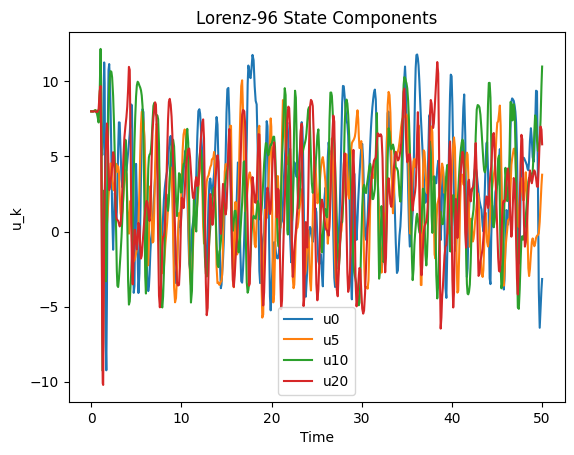

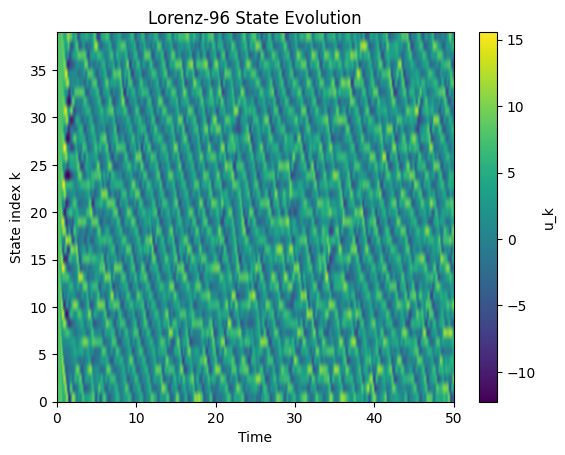

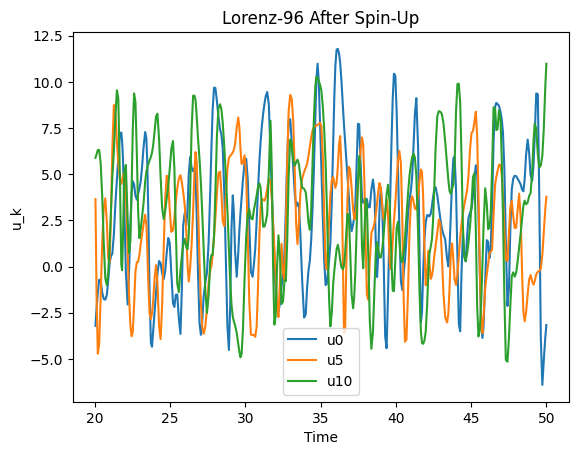

In [26]:
K = 40
F = 8
d = 1

u = F*np.ones(K)
u[0] += 0.01

t_span = (0,50)

sol = solve_ivp(
    lorenz96,
    t_span,
    u,
    args=(K,F,d)
)
final_state = sol.y[:,-1]

plt.figure()

plt.plot(sol.t, sol.y[0], label='u0')
plt.plot(sol.t, sol.y[5], label='u5')
plt.plot(sol.t, sol.y[10], label='u10')
plt.plot(sol.t, sol.y[20], label='u20')

plt.xlabel('Time')
plt.ylabel('u_k')
plt.title('Lorenz-96 State Components')
plt.legend()

plt.show()

plt.figure()

plt.imshow(
    sol.y,
    aspect='auto',
    origin='lower',
    extent=[sol.t[0], sol.t[-1], 0, K-1]
)

plt.xlabel('Time')
plt.ylabel('State index k')
plt.title('Lorenz-96 State Evolution')

plt.colorbar(label='u_k')

plt.show()

mask = sol.t > 20

plt.figure()

plt.plot(sol.t[mask], sol.y[0, mask], label='u0')
plt.plot(sol.t[mask], sol.y[5, mask], label='u5')
plt.plot(sol.t[mask], sol.y[10, mask], label='u10')

plt.xlabel('Time')
plt.ylabel('u_k')
plt.title('Lorenz-96 After Spin-Up')
plt.legend()

plt.show()

